# Random-Number Generators

Pseudo-random number generators (PRNGs) are algorithms that produce sequences of numbers that approximate the properties of random numbers. They are deterministic, meaning that if you know the initial state (or seed) of the generator, you can predict the entire sequence of numbers it will produce. However, they are designed to be statistically indistinguishable from true random numbers for most applications.

## Mid Square Method
The Mid Square method is a simple PRNG that works by squaring a number and then taking the middle digits of the result as the next number in the sequence. 

In [1]:
def mid_square(seed, n):
    """Generate a sequence of pseudo-random numbers using the Mid Square method."""
    results = []
    for _ in range(n):
        squared = seed ** 2
        squared_str = str(squared).zfill(8)  # Ensure it's 8 digits long
        
        mid_digits = squared_str[2:6]
        seed = int(mid_digits)
        results.append(seed)
    return results

mid_square(1234, 10)

[5227, 3215, 3362, 3030, 1809, 2724, 4201, 6484, 422, 1780]

## Linear Congruential Generator (LCG)

The Linear Congruential Generator is one of the oldest and simplest PRNGs. It uses a linear equation to generate the next number in the sequence based on the current number. The formula is:

$$X_{n+1} = (a \times X_n + c) \mod m$$


### Implementation of LCG

In [2]:
def linear_congruential_generator(seed, a, c, m, num_values=1):
    random_numbers = []

    for _ in range(num_values):
        seed = (a * seed + c) % m
        random_numbers.append(seed/m)  # Normalize to [0, 1]
    
    return random_numbers

linear_congruential_generator(seed=1, a=1664525, c=1013904223, m=2**32, num_values=5)

[0.23645552527159452,
 0.3692706737201661,
 0.5042420323006809,
 0.7048832636792213,
 0.05054362863302231]

### Plot

Text(0, 0.5, 'Frequency')

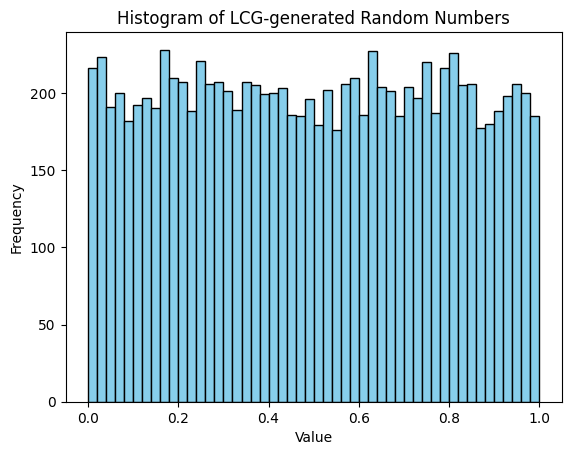

In [3]:
import matplotlib.pyplot as plt

plt.hist(
    linear_congruential_generator(
        seed=1, a=1664525, c=1013904223, m=2**32, num_values=10000
    ),
    color="skyblue",
    edgecolor="black",
    bins=50,
)
plt.title("Histogram of LCG-generated Random Numbers")
plt.xlabel("Value")
plt.ylabel("Frequency")

## Some other Congruential Generators
- Mixed Multiplicative Congruential Generator (MMCG)
- Multiplicative Congruential Generator (MCG)
- Additive Congruential Generator (ACG)
- Arithmetic Congruential Generator (ACG)
- Combined Congruential Generator (CCG)

### Mixed multiplicative method

In [4]:
def mixed_multiplicative_congruential(seed, a, b, m, n):
    numbers = []
    for _ in range(n):
        seed = (a * seed + b) % m
        numbers.append(seed)
    return numbers

print(mixed_multiplicative_congruential(1, 13, 1, 19, 20))

[14, 12, 5, 9, 4, 15, 6, 3, 2, 8, 10, 17, 13, 18, 7, 16, 0, 1, 14, 12]


### Multiplicative congruential method

In [5]:
def multiplicative_congruential(seed, a, m, n):
    numbers = []
    for _ in range(n):
        seed = (a * seed) % m
        numbers.append(seed)
    return numbers

print(multiplicative_congruential(1, 13, 19, 20))

[13, 17, 12, 4, 14, 11, 10, 16, 18, 6, 2, 7, 15, 5, 8, 9, 3, 1, 13, 17]


### Additive congruential method

In [6]:
def additive_congruential(seed, b, m, n):
    numbers = []
    for _ in range(n):
        seed = (seed + b) % m
        numbers.append(seed)
    return numbers

print(additive_congruential(1, 11, 19, 20))

[12, 4, 15, 7, 18, 10, 2, 13, 5, 16, 8, 0, 11, 3, 14, 6, 17, 9, 1, 12]


### Arithmetic congruential method

In [7]:
def arithmetic_congruential(r1, r2, m, n):
    numbers = []
    for _ in range(n):
        r1, r2 = (r1 + r2) % m, r1
        numbers.append(r1)
    return numbers

print(arithmetic_congruential(13, 9, 17, 20))

[5, 1, 6, 7, 13, 3, 16, 2, 1, 3, 4, 7, 11, 1, 12, 13, 8, 4, 12, 16]


### Combined congruential method

In [8]:
def combined_congruential(i, j, a1, b1, m1, a2, b2, m2, n):
    numbers = []
    for _ in range(n):
        i = (a1 * i + b1) % m1
        j = (a2 * j + b2) % m2
        numbers.append((i - j) % max(m1, m2))
    return numbers

print(combined_congruential(1, 1, 13, 1, 19, 17, 1, 23, 20))

[19, 4, 6, 2, 22, 21, 15, 17, 9, 11, 14, 15, 1, 20, 17, 1, 20, 18, 3, 8]
